<a href="https://colab.research.google.com/github/Darren0099/Al-manRaffli/blob/main/PerintahDataAnalisis_Day03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install google-cloud-bigquery pandas-gbq

In [3]:
from google.colab import auth
auth.authenticate_user()

In [6]:
import pandas as pd

In [8]:
query = """
SELECT *
FROM `carrernextbootcamp.furniture.sales`
"""

df = pd.read_gbq(
    query,
    project_id='carrernextbootcamp'
)

/tmp/ipykernel_2627/1980672146.py:6: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(


In [9]:
df.head()

,year,month,day,sales_date_std,order_id,customer_name,product_name,category,price,quantity,discount,total,shipping_fee,total_sales,status,shipping_address,kota,string_field_17,string_field_18
0,2025,6,6,45814,ORD00382,Customer_3241,Rak Meja,Ruang Kerja,750000,3,0,1,2025000,50000,2075000,completed,Kelurahan 173,Bekasi,Bekasi
1,2025,2,2,45690,ORD00571,Customer_2064,Nakas,Kamar Tidur,1000000,3,0,1,2700000,50000,2750000,completed,Kelurahan 52,Bekasi,Bekasi
2,2025,9,9,45909,ORD00868,Customer_2665,Meja Makan,Ruang Makan,3200000,2,0,1,5760000,50000,5810000,cancelled,Kelurahan 22,Bekasi,Bekasi
3,2025,10,10,45940,ORD01341,Customer_2929,Meja,Ruang Kerja,1250000,2,0,1,2250000,50000,2300000,completed,Kelurahan 101,Bekasi,Bekasi
4,2025,5,5,45782,ORD01388,Customer_902,Nakas,Kamar Tidur,1000000,1,0,1,900000,50000,950000,completed,Kelurahan 29,Bekasi,Bekasi


In [13]:
pivot = pd.pivot_table(
    df,
    values='total_sales',
    index='category',
    columns='status',
    aggfunc='sum',
    fill_value=0
)

print(pivot)

status       1050000  1175000  1185000  1215500  1220000  12210000  1225500  \
category                                                                      
Dapur              0        0        0        0        0         0        0   
Kamar Tidur        0        0        0        0        0         0        0   
Penyimpanan   180000        0        0        0    50000         0        0   
Ruang Kerja        0   100000   300000        0        0         0        0   
Ruang Makan        0        0        0    50000   150000         0   240000   
Ruang Tamu         0        0        0        0        0    300000        0   

status       1230000  12875000  12885000  ...  8835000  950000  9500000  \
category                                  ...                             
Dapur              0         0         0  ...        0       0        0   
Kamar Tidur        0    100000    240000  ...        0  200000   100000   
Penyimpanan   480000         0         0  ...        0       0     

In [12]:
#canceled kota terbanyak
cancelled_city = (
    df[df['status'] == 'cancelled']
    .groupby('kota')
    .size()
    .sort_values(ascending=False)
)

print(cancelled_city)

kota
Bekasi               64
Jakarta Utara        60
Jakarta Pusat        55
Jakarta Selatan      51
Depok                51
Tangerang            48
Jakarta Timur        44
Jakarta Barat        44
Tangerang Selatan    44
Bogor                41
dtype: int64


kota
Jakarta Utara        5621605000
Jakarta Pusat        5509810000
Jakarta Barat        5397715000
Jakarta Selatan      5317415000
Depok                5203910000
Bogor                5127120000
Jakarta Timur        4978305000
Tangerang Selatan    4941210000
Name: total_sales, dtype: Int64


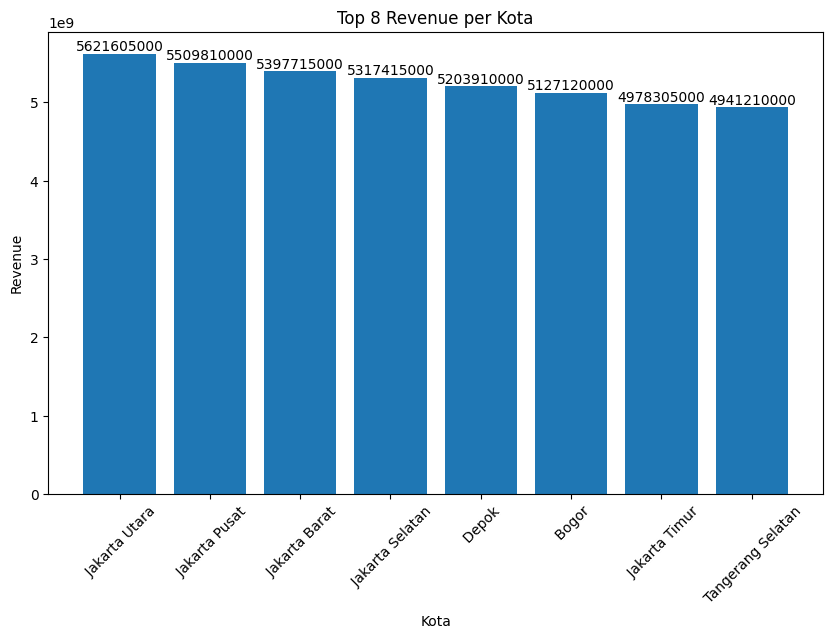

In [14]:
import matplotlib.pyplot as plt

top_city = (
    df.groupby('kota')['total_sales']
    .sum()
    .sort_values(ascending=False)
    .head(8)
)

print(top_city)

plt.figure(figsize=(10,6))

bars = plt.bar(
    top_city.index,
    top_city.values
)

plt.title('Top 8 Revenue per Kota')
plt.xlabel('Kota')
plt.ylabel('Revenue')


for bar in bars:
    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        round(yval,2),
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)

plt.show()

month
1     863
2     809
3     827
4     842
5     840
6     843
7     888
8     881
9     799
10    836
11    790
12    782
dtype: int64


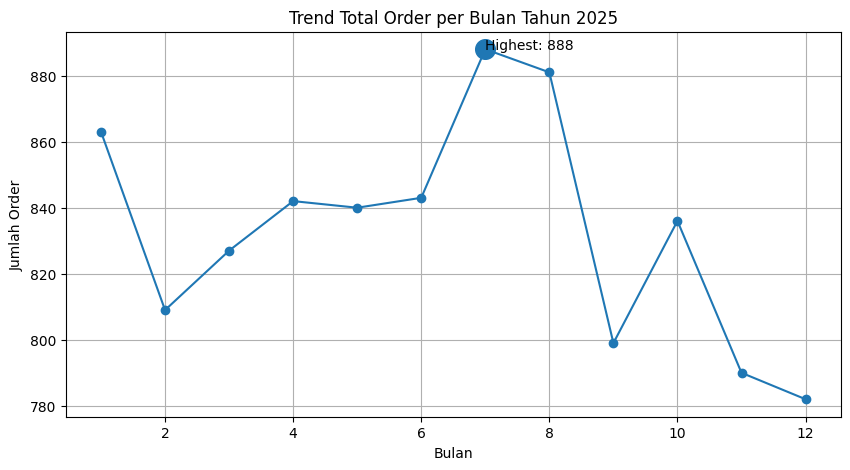

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# Menghitung total order per bulan tahun 2025
monthly_order = (
    df[df['year'] == 2025]
    .groupby('month')
    .size()
)

print(monthly_order)

# Menentukan bulan dengan order tertinggi
max_month = monthly_order.idxmax()
max_value = monthly_order.max()

# Membuat line chart
plt.figure(figsize=(10,5))

plt.plot(
    monthly_order.index,
    monthly_order.values,
    marker='o'
)

# Highlight bulan tertinggi
plt.scatter(
    max_month,
    max_value,
    s=200
)

# Menambahkan label
plt.text(
    max_month,
    max_value,
    f'Highest: {max_value}'
)

plt.title('Trend Total Order per Bulan Tahun 2025')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Order')

plt.grid(True)

plt.show()